# ORAS5 Classification Test

In this notebook, I apply simple machine learning techniques to ORAS5 reanalysis data. 

I follow a similar structure to the 'whats_my_age_again' notebook:  

1. Load and process the data  
2. Construct machine learning features  
3. Define a binary target (pre/post 1970)  
4. Split into training and testing sets  
5. Perform feature selection  
6. Train an AdaBoost classifier  
7. Evaluate performance  
8. Examine correlations and feature importance  

Note: To make things easier, for this first pass I took the spatial mean over the whole area for each variable.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

## Data Setup

I define the location of the ORAS5 boxed files, specify which variables to load, and define the North Atlantic spatial domain.  

The files follow the naming convention:

ORAS5_YYYY_MM_token_boxed.nc

I also specify which variables require depth averaging (0–100 m).

In [2]:
DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

VARIABLE_TOKENS = {
    "sst": "sst",
    "salinity": "so_salinity",
    "u": "u_zonal",
    "v": "v_meridional",
    "thetao": "thetao_potential_temperature",
    "qnet": "net_downward_heat_flux",
}

REGION = dict(lat_min=2, lat_max=90, lon_min=-80, lon_max=2)

FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

DEPTH_MODE = {
    "sst": None,
    "salinity": "0_100m",
    "u": "0_100m",
    "v": "0_100m",
    "thetao": "0_100m",
    "qnet": None,
}

MID_DATE = pd.Timestamp("1970-01-01")

## Helper Functions

I then define helper functions to:

- Identify files for each variable  
- Extract time from the filename  
- Subset to the region (if coordinates exist)  
- Reduce depth (if required)  
- Compute spatial means  

If coordinate information is absent in a file, I assume it has already been spatially boxed.

In [3]:
def files_for_token(data_dir, token):
    all_nc = list(data_dir.rglob("*.nc"))
    return sorted([p for p in all_nc if FILE_RE.search(p.name) and (token in p.name)])

def time_from_filename(path):
    m = FILE_RE.search(path.name)
    return pd.Timestamp(year=int(m.group(1)), month=int(m.group(2)), day=1)

def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da
    
    for zname in ["depth", "deptht", "nav_lev"]:
        if zname in da.dims:
            z = ds[zname]
            return da.where((z >= 0) & (z <= 100), drop=True).mean(dim=zname)
    
    return da

def spatial_mean(da):
    return da.mean(dim=[d for d in da.dims])

## Building the Feature Table

I then loop through each variable, compute the spatial mean value for every month, and assemble a feature matrix where:

Rows = months  
Columns = spatial mean variables

In [5]:
from netCDF4 import Dataset
import time

def file_varname(path):
    # Return the first real data variable name in a file
    with Dataset(path, "r") as nc:
        ignore = {"time", "time_counter", "nav_time", "lat", "lon", "nav_lat", "nav_lon", "depth", "deptht", "nav_lev"}
        candidates = [k for k in nc.variables.keys() if k not in ignore]
        if not candidates:
            raise ValueError(f"No usable variables found in {path}")
        return candidates[0]

def fast_file_mean(path):
    # Compute the spatial mean of the main variable in a file (fast way)
    with Dataset(path, "r") as nc:
        vname = file_varname(path)
        arr = nc.variables[vname][:]
        return float(np.nanmean(arr))

series_list = []
t0 = time.time()

for var, token in VARIABLE_TOKENS.items():
    paths = files_for_token(DATA_DIR, token)
    if len(paths) == 0:
        raise FileNotFoundError(f"No files found for token={token}")

    times = []
    vals = []

    print(f"\n[{var}] files: {len(paths)}")

    for i, p in enumerate(paths, start=1):
        if (i == 1) or (i % 50 == 0):
            print(f"  {i}/{len(paths)}  {p.name}")

        times.append(time_from_filename(p))
        vals.append(fast_file_mean(str(p)))

    s = pd.Series(vals, index=pd.DatetimeIndex(times), name=var).sort_index()
    series_list.append(s)

X = pd.concat(series_list, axis=1).sort_index().dropna()

print("\nFeature matrix shape:", X.shape)
print("Elapsed (s):", round(time.time() - t0, 1))
display(X.head())


[sst] files: 491
  1/491  ORAS5_1958_01_sst_boxed.nc
  50/491  ORAS5_1962_02_sst_boxed.nc
  100/491  ORAS5_1966_04_sst_boxed.nc
  150/491  ORAS5_1970_06_sst_boxed.nc
  200/491  ORAS5_1974_08_sst_boxed.nc
  250/491  ORAS5_1978_10_sst_boxed.nc
  300/491  ORAS5_1982_12_sst_boxed.nc
  350/491  ORAS5_1987_02_sst_boxed.nc
  400/491  ORAS5_1992_08_sst_boxed.nc
  450/491  ORAS5_2003_12_sst_boxed.nc

[salinity] files: 409
  1/409  ORAS5_1958_01_so_salinity_boxed.nc
  50/409  ORAS5_1962_02_so_salinity_boxed.nc
  100/409  ORAS5_1966_04_so_salinity_boxed.nc
  150/409  ORAS5_1970_06_so_salinity_boxed.nc
  200/409  ORAS5_1974_08_so_salinity_boxed.nc
  250/409  ORAS5_1978_10_so_salinity_boxed.nc
  300/409  ORAS5_1982_12_so_salinity_boxed.nc
  350/409  ORAS5_1993_10_so_salinity_boxed.nc
  400/409  ORAS5_2014_01_so_salinity_boxed.nc

[u] files: 414
  1/414  ORAS5_1958_01_u_zonal_boxed.nc
  50/414  ORAS5_1962_02_u_zonal_boxed.nc
  100/414  ORAS5_1966_04_u_zonal_boxed.nc
  150/414  ORAS5_1970_06_u_zonal

,sst,salinity,u,v,thetao,qnet
1958-01-01,12.704071,35.035698,0.003940,-0.000637,9.440746,-124.837936
1958-02-01,12.375930,35.044914,0.002558,-0.000101,9.283197,-78.086128
1958-03-01,12.443035,35.054279,0.001734,0.000241,9.279761,-30.927570
1958-04-01,12.813393,35.054077,0.002941,0.000415,9.387774,19.134275
1958-05-01,13.537451,35.037258,0.002031,0.001976,9.624366,56.084602


## Defining the Target Variable

I define a binary classification target (arbitrarily at this stage):

0 = pre-1970  
1 = post-1970

In [6]:
y = pd.Series((X.index >= MID_DATE).astype(int), index=X.index)

print("Class balance:", y.value_counts().to_dict())

Class balance: {1: 188, 0: 144}


## Train/Test Split

To remain consistent with the original notebook I perform a stratified random split.  

This ensures that both pre and post appear in the training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print("Train balance:", y_train.value_counts().to_dict())
print("Test balance:", y_test.value_counts().to_dict())

Train balance: {1: 150, 0: 115}
Test balance: {1: 38, 0: 29}


## Feature Selection

I then test each variable individually to see how strongly it differs between pre and post 1970 months and I keep the variables that show the largest differences.

In [8]:
selector = SelectKBest(score_func=f_classif, k=6)
selector.fit(X_train, y_train)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

selected_cols = X.columns[selector.get_support()]
print("Selected features:", selected_cols.tolist())

Selected features: ['sst', 'salinity', 'u', 'v', 'thetao', 'qnet']


## Model Training

I then train an AdaBoost classifier using decision trees as base estimators + feature scaling.

In [9]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=200,
        random_state=1
    ))
])

model.fit(X_train_sel, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,DecisionTreeC...r(max_depth=5)
,n_estimators,200
,learning_rate,1.0
,algorithm,'deprecated'


## Model Evaluation

I evaluate performance using:

- Classification report  
- Confusion matrix  
- ROC curve  
- AUC score  

This allows me to assess how well the basin-mean state distinguishes climate regimes.

              precision    recall  f1-score   support

           0       0.82      0.79      0.81        29
           1       0.85      0.87      0.86        38

    accuracy                           0.84        67
   macro avg       0.83      0.83      0.83        67
weighted avg       0.84      0.84      0.84        67

Confusion matrix:
 [[23  6]
 [ 5 33]]


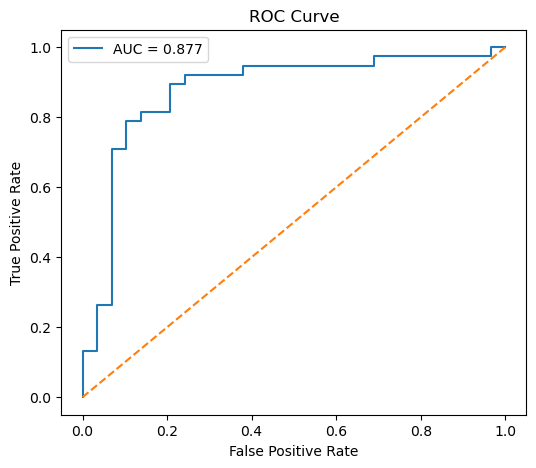

In [10]:
pred = model.predict(X_test_sel)
proba = model.predict_proba(X_test_sel)[:, 1]

print(classification_report(y_test, pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

## Correlation Matrix

I compute the correlation matrix.

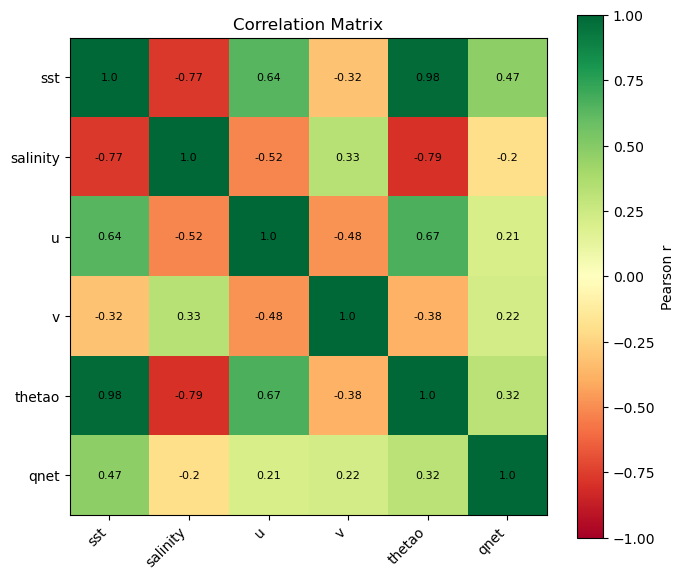

In [14]:
corr = X.corr().round(2)

plt.figure(figsize=(7,6))
im = plt.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson r")

labels = corr.columns
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, corr.iloc[i,j],
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Feature Importance

Finally, I plot the importance of each variable.

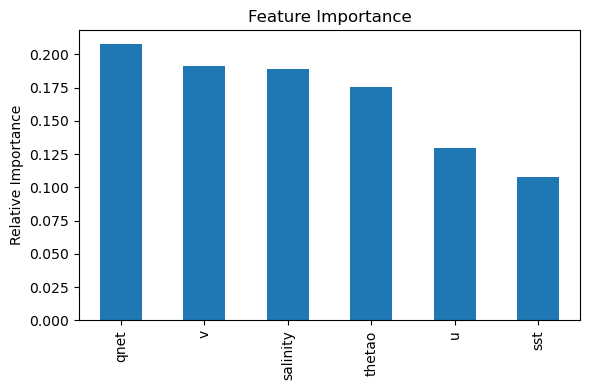

qnet        0.207618
v           0.190845
salinity    0.188928
thetao      0.175197
u           0.129611
sst         0.107801
dtype: float64


In [12]:
importances = model.named_steps["clf"].feature_importances_
imp = pd.Series(importances, index=selected_cols).sort_values(ascending=False)

plt.figure(figsize=(6,4))
imp.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Relative Importance")
plt.tight_layout()
plt.show()

print(imp)